<a href="https://colab.research.google.com/github/nimitha123-kd/Take-IT-Smart-Internship/blob/main/House_Price_Regression_Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Machine Learning Task: House Price Prediction (Regression)***

# **Problem Statement**

- The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.


- Students are required to analyze the dataset, perform data preprocessing, apply feature
 engineering techniques, train multiple regression models, and evaluate their performance to
 identify the best model for predicting house prices.

# **Objective**

# The objective of this task is to:

 ● Understand and explore the housing dataset.

● Perform data preprocessing including handling missing values, duplicates, and outliers.

● Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.

● Apply encoding, log transformation, and feature scaling where necessary.

● Train multiple regression algorithms to predict house prices.

● Evaluate and compare model performance using appropriate evaluation metrics.

# **TASKS**


# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#  If any warnings are disturbing the buliding of model , then use these  libraries.
# import warnings
# warnings.filterwarnings('ignore')

# **Load Dataset**

In [ ]:
# Dataset or the dataframe ==> data or df
data = pd.read_csv('house_price_regression_dataset.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


# **Basic Checks / Check Dataset**

In [ ]:
# first 5 rows
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
# Last 5 rows
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
# Overveiw about the data frame
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
# Numerical Summary
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [ ]:
# All columns
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
# All rows / index
data.index

RangeIndex(start=0, stop=1000, step=1)

In [ ]:
#Show only columns containg numericals
num_colms=data.select_dtypes(include=["float64","int64"])
num_colms


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [ ]:
# Show only columns containing letters/categories.
cat_colms=data.select_dtypes(include=["object"])
cat_colms

""
0
1
2
3
4
...
995
996
997
998


In [ ]:
# unique
for x in cat_colms:
   print(x,"--->",data[x].unique())

In [ ]:
# value counts
for x in num_colms:
  print(data[x].value_counts())

Square_Footage
3419    3
4219    3
4646    3
1743    3
2292    2
       ..
1269    1
4926    1
966     1
3592    1
4272    1
Name: count, Length: 894, dtype: int64
Num_Bedrooms
2    215
5    205
1    201
4    197
3    182
Name: count, dtype: int64
Num_Bathrooms
1    350
2    327
3    323
Name: count, dtype: int64
Year_Built
1996    24
1977    22
2008    21
1983    21
2017    21
        ..
1980     8
2001     8
2020     8
1951     6
1963     5
Name: count, Length: 73, dtype: int64
Lot_Size
3.108790    1
0.599637    1
4.753014    1
3.634823    1
2.730667    1
           ..
4.781489    1
3.978440    1
3.555040    1
3.941604    1
1.014286    1
Name: count, Length: 1000, dtype: int64
Garage_Size
2    343
1    336
0    321
Name: count, dtype: int64
Neighborhood_Quality
10    123
5     109
2     105
7     102
6     101
4      99
8      97
1      91
9      88
3      85
Name: count, dtype: int64
House_Price
742599.253332    1
262382.852274    1
985260.854490    1
777977.390119    1
229698.91866

In [ ]:
# Value count
for x in cat_colms:
  print(data[x].value_counts())

### **How to handle Missing values**

1. Can we drop  missing values
   - We can drop missing values if there are few values missing.
   - Dropping missing is not recommended when huge values are missing as it results in loss of information.
   - Drop the column when % of missing values is greater than 70%.

2. Can we replace them with values
  - We can use domain knowledge and replace.
  - We can replace with either mean or median or mode.

3. When to use mode
  - use mode when categorical/text data is missing

4. When to use mean or median
  - use when missing value is numerical.
  - Use mean when data distribution is normal.
  - Use median when data distribution is skewed(left skewed or right skewed).

In [ ]:
data.isnull().sum()


,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


# Here since there is no missing values the dropping is skipped.

In [ ]:
# No missing values.
# if missing values present less than 5% , then use data.dropna()
# if 45% to 60% , then use data.fillna()
# if more than that use data.drop(columns="column_name",inplace=True), which dealets the whole column.

# **Remove Duplicate Records**

If duplicates are present just drop them.
  - data.drop_duplicates(inplace=True)
  - data.drop_duplicates(subset="column_name")

In [ ]:
data.duplicated().sum()

np.int64(0)

# Data Wragling
- merge
- drop
- create new column
- rename columns.

In [ ]:
data.rename(columns={"Neighborhood_Quality": "Neighborhood_Rating"}, inplace=True)
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Rating,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [ ]:
# Merging , this creates the new column.
data['Total_Size'] = data['Square_Footage'] + data['Lot_Size']
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Rating,House_Price,Total_Size
0,1360,2,1,1981,0.599637,0,5,2.623829e+05,1360.599637
1,4272,3,3,2016,4.753014,1,6,9.852609e+05,4276.753014
2,3592,1,2,2016,3.634823,0,9,7.779774e+05,3595.634823
3,966,1,2,1977,2.730667,1,8,2.296989e+05,968.730667
4,4926,2,1,1993,4.699073,0,8,1.041741e+06,4930.699073
...,...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05,3263.165110
996,3179,1,2,1999,2.977123,1,10,6.837232e+05,3181.977123
997,2606,4,2,1962,4.055067,0,2,5.720240e+05,2610.055067
998,4723,5,2,1950,1.930921,0,7,9.648653e+05,4724.930921


# **Exploratory Data Analysis**




### **Univariate analysis**
Analysing single variable / column
- histogram: used when values are numeric/continuos , when most values are unique.
- count plot : categorical ivalues, small numbers like 1,2,3,4
- box plot : numerical values , somtimes compares the categorical values vs the numerical values.

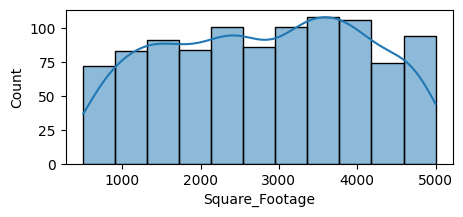

In [ ]:
# HISTOGRAM => checks the distribution.
# Square_Footage
plt.figure(figsize=(5,2))
sns.histplot(data,x="Square_Footage",kde=True)
plt.show()


In [ ]:
# cheching the datatype of Square_Footage
data.loc[: , "Square_Footage"].dtype

dtype('int64')

In [ ]:
# checking whether left/right skew  or Normal distribution.
data.loc[ : , "Square_Footage"].skew()


np.float64(-0.06600064579808387)

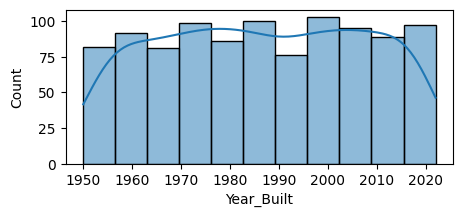

In [ ]:
# Year_Built
plt.figure(figsize=(5,2))
sns.histplot(data,x="Year_Built",kde=True)
plt.show()


In [ ]:
# checking the datatype of Year_Built
data.loc[: , "Year_Built"].dtype


dtype('int64')

In [ ]:
# checking whether left/right skew  or Normal distribution.
data.loc[ : , "Year_Built"].skew()


np.float64(-0.021253592163707695)

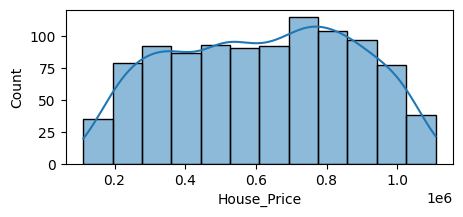

In [ ]:
# House_Price
plt.figure(figsize=(5,2))
sns.histplot(data,x="House_Price",kde=True)
plt.show()


In [ ]:
# checking the datatype of
data.loc[: , "House_Price"].dtype


dtype('float64')

In [ ]:
# checking whether left/right skew  or Normal distribution.
data.loc[ : , "House_Price"].skew()


np.float64(-0.06395513907654668)

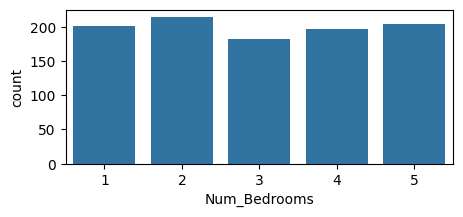

In [ ]:
# Count => The frequency.
#Num_Bedrooms
plt.figure(figsize=(5,2))
sns.countplot(data,x="Num_Bedrooms")
plt.show()

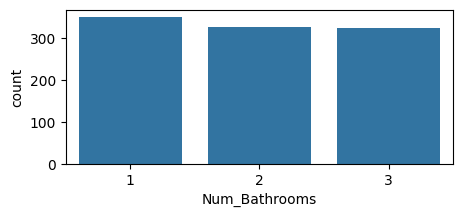

In [ ]:
#
plt.figure(figsize=(5,2))
sns.countplot(data,x="Num_Bathrooms")
plt.show()

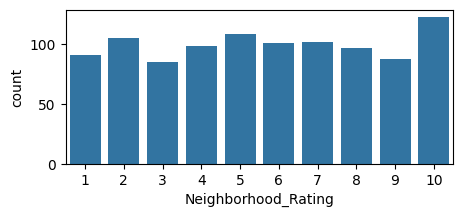

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data,x="Neighborhood_Rating")
plt.show()

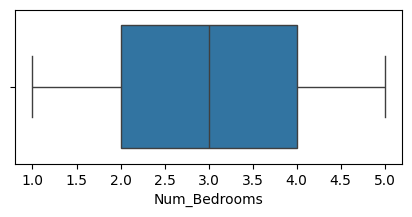

In [ ]:
# Box plot
plt.figure(figsize=(5,2))
sns.boxplot(data,x="Num_Bedrooms")
plt.show()

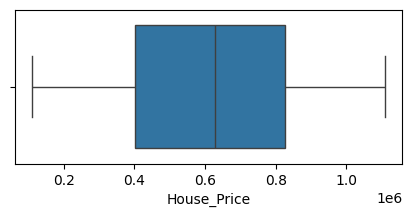

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(data,x="House_Price")
plt.show()

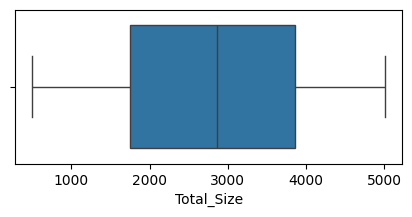

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(data,x="Total_Size")
plt.show()

## **Bivariate Analysis**
Analysing two variables/columns
* Scatter: when they are 2 numerical columns.
* line: When x-axis is time( or odered data)
* bar plot: When x is categorical & y is numerical.

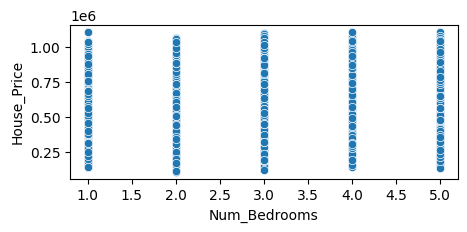

In [ ]:
# check the relationship between House_Price &	Num_Bedrooms
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Num_Bedrooms',y='House_Price')
plt.show()

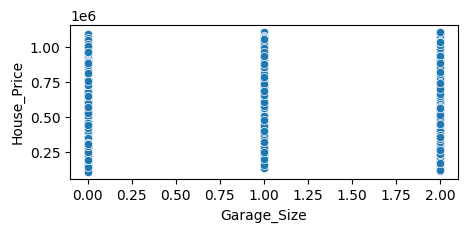

In [ ]:
# check the relationship between Garage_Siz & House_Price
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Garage_Size',y='House_Price')
plt.show()

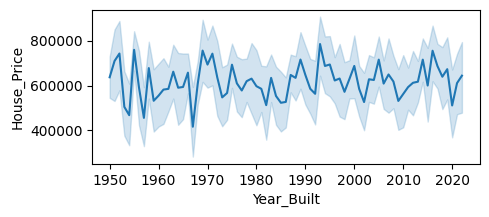

In [ ]:
# Line Plot
plt.figure(figsize=(5,2))
sns.lineplot(data,x='Year_Built',y='House_Price')
plt.show()

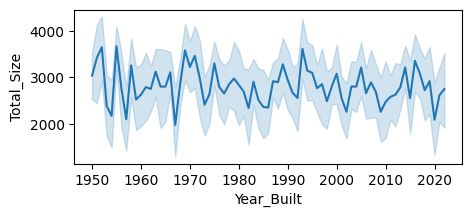

In [ ]:
plt.figure(figsize=(5,2))
sns.lineplot(data,x='Year_Built',y='Total_Size')
plt.show()

In [ ]:
# NO Categorical column in this data set.
# Therefore no Bar plots.

# **Multivariate Analysis**
- Find important columns
- Remove useless columns
-Check relationships between many features
- Understand how features affect the target column

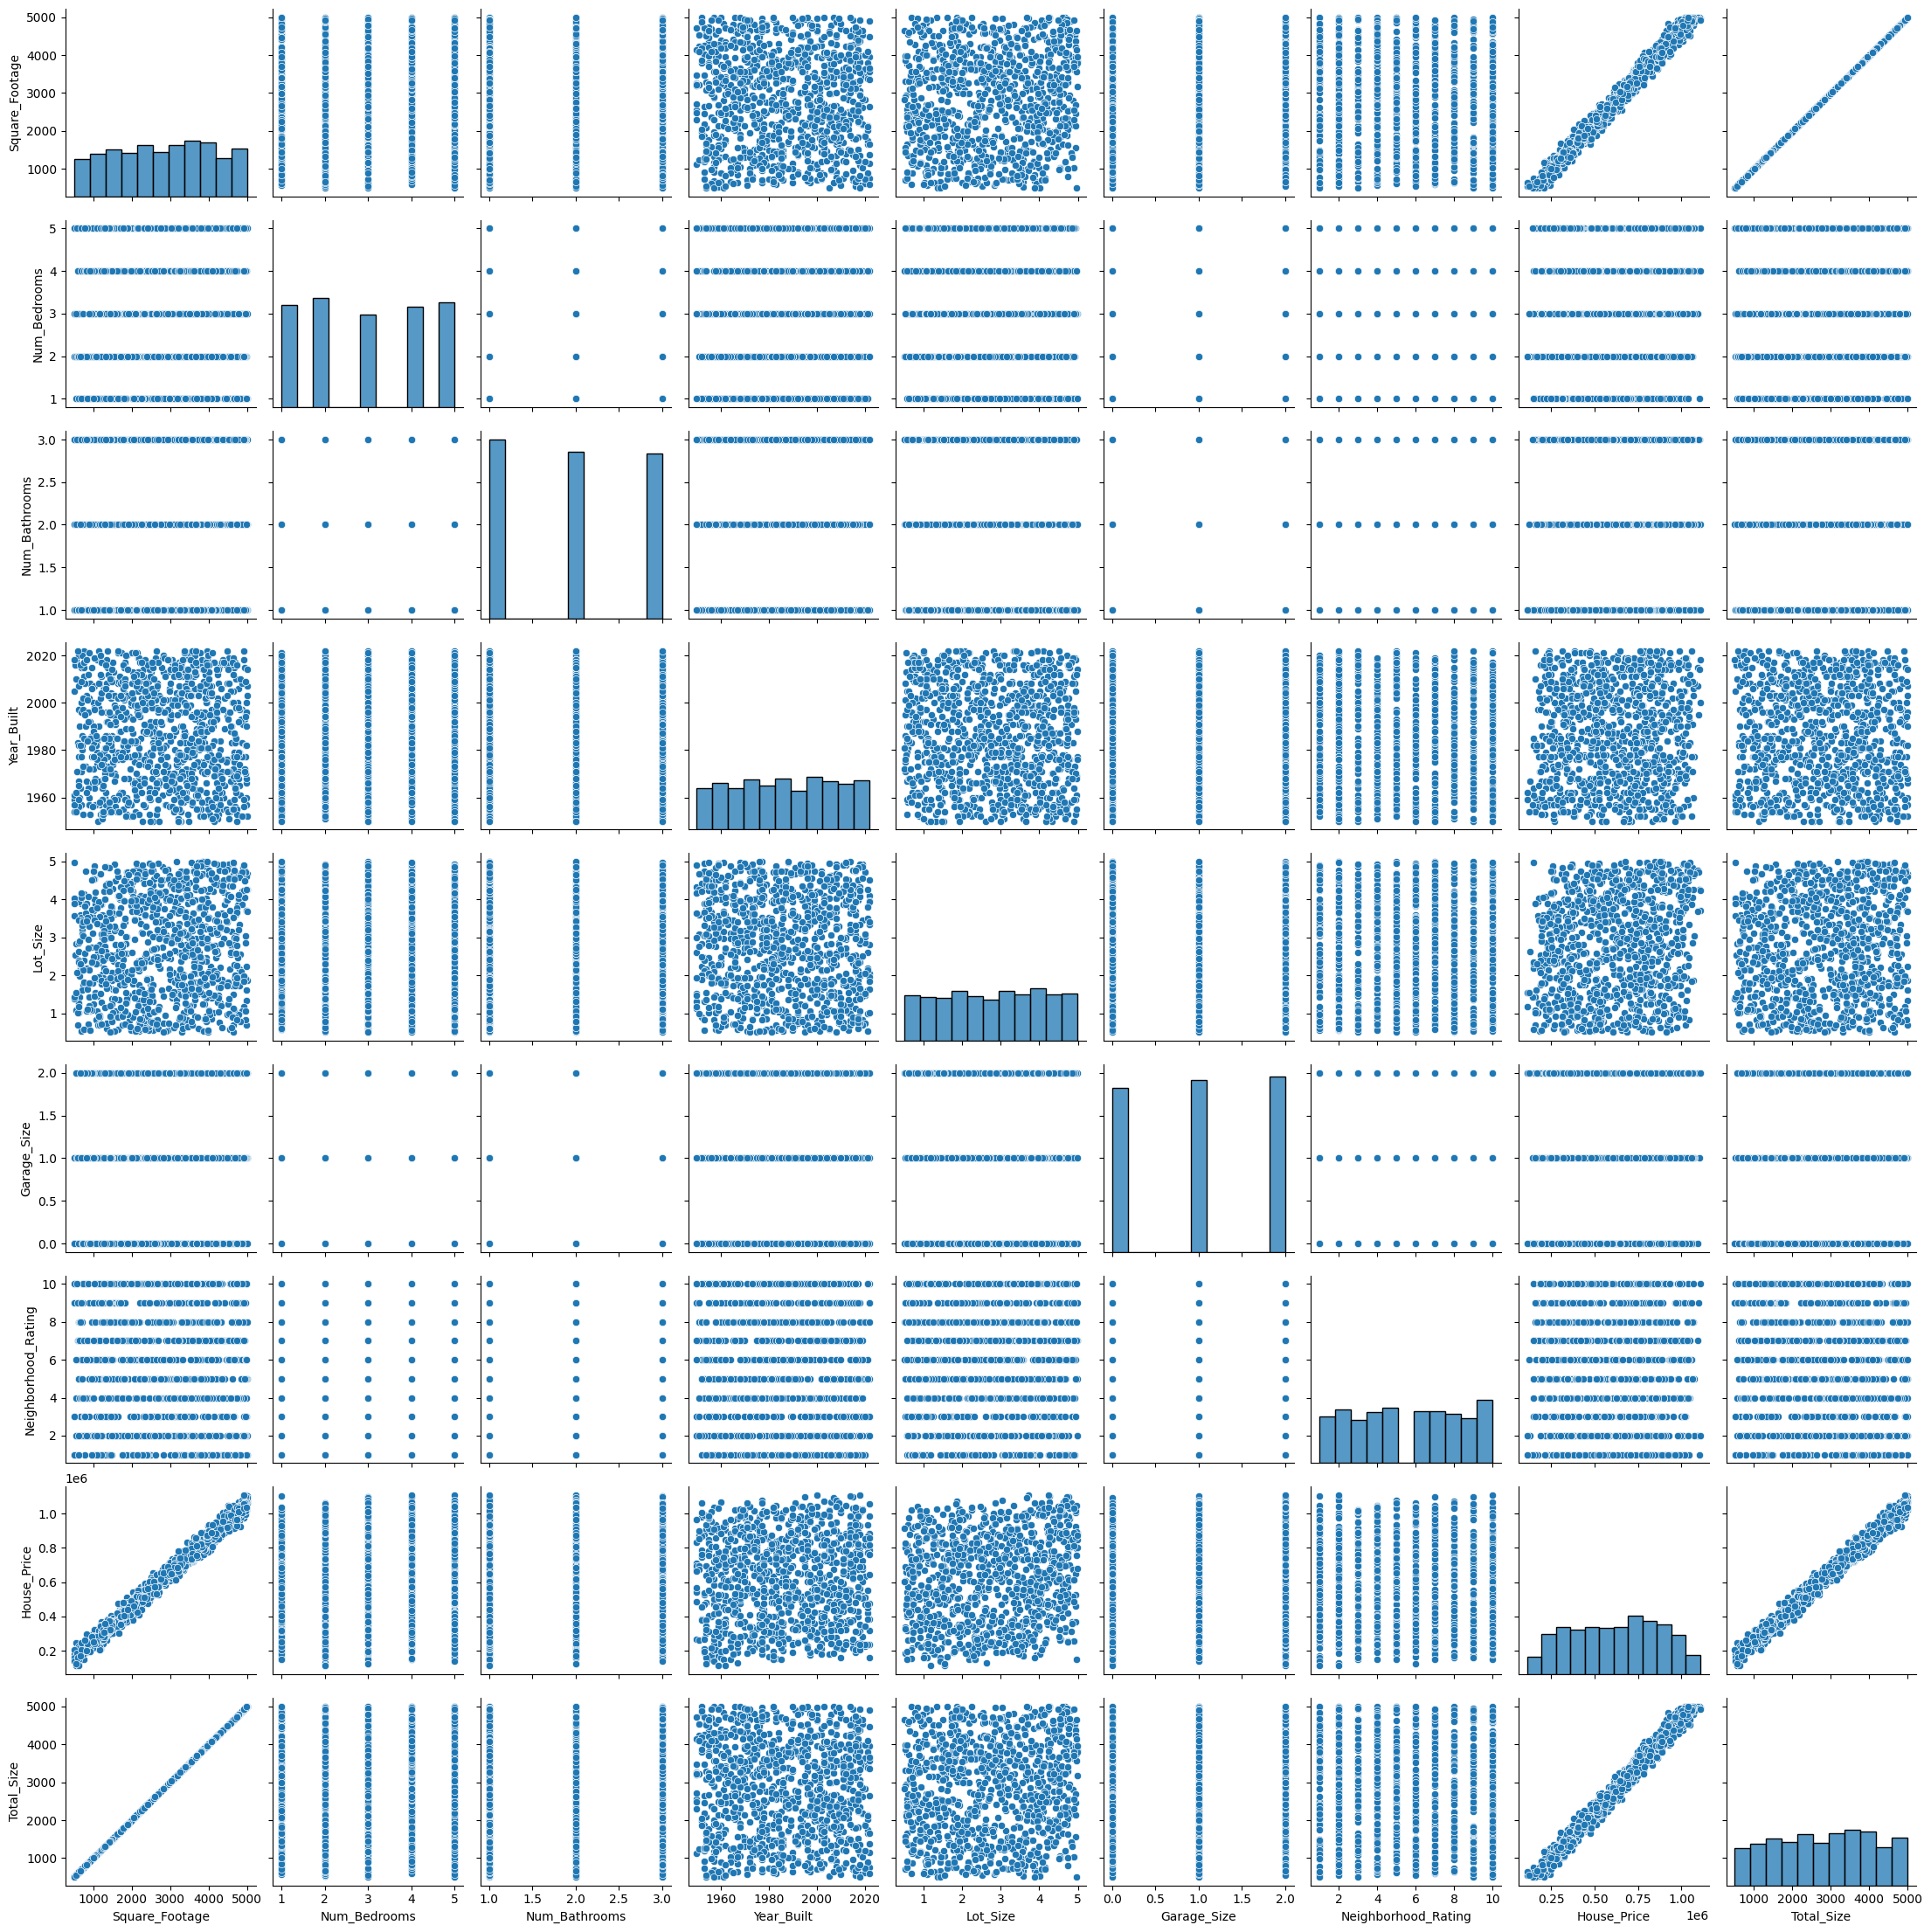

In [ ]:
# pairplot: It creates scatter plot among all the numerical variables
sns.pairplot(data)

In [ ]:
# heat map : Used to visualise the correlation
# Correlation measures how strong two variables

num_colms.corr()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


<Axes: >

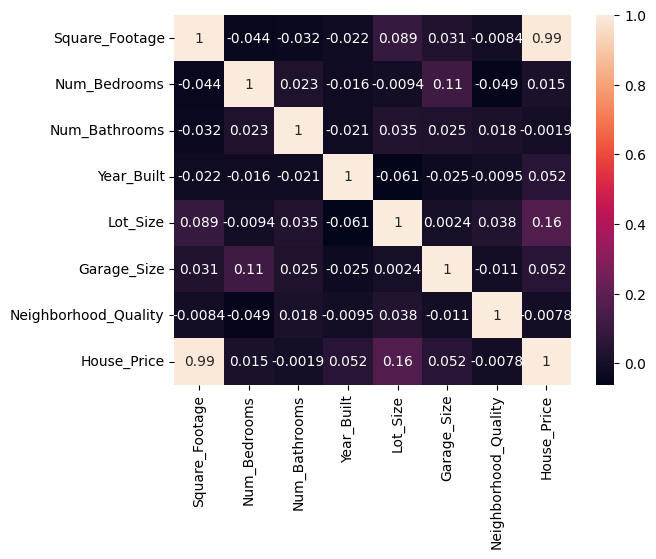

In [ ]:
sns.heatmap(num_colms.corr(),annot=True)

In [ ]:
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Rating,House_Price,Total_Size
0,1360,2,1,1981,0.599637,0,5,2.623829e+05,1360.599637
1,4272,3,3,2016,4.753014,1,6,9.852609e+05,4276.753014
2,3592,1,2,2016,3.634823,0,9,7.779774e+05,3595.634823
3,966,1,2,1977,2.730667,1,8,2.296989e+05,968.730667
4,4926,2,1,1993,4.699073,0,8,1.041741e+06,4930.699073
...,...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05,3263.165110
996,3179,1,2,1999,2.977123,1,10,6.837232e+05,3181.977123
997,2606,4,2,1962,4.055067,0,2,5.720240e+05,2610.055067
998,4723,5,2,1950,1.930921,0,7,9.648653e+05,4724.930921


## **Handle Outliers**

Outliers are extreme values which are far away from actual data or range.

Eg: Age of students : [20,21,22,23,24,98,100]

In this 98 and 100 are outliers.

**Ways to Identify Outliers**
- Box plot
- Sactter plot
- histogram

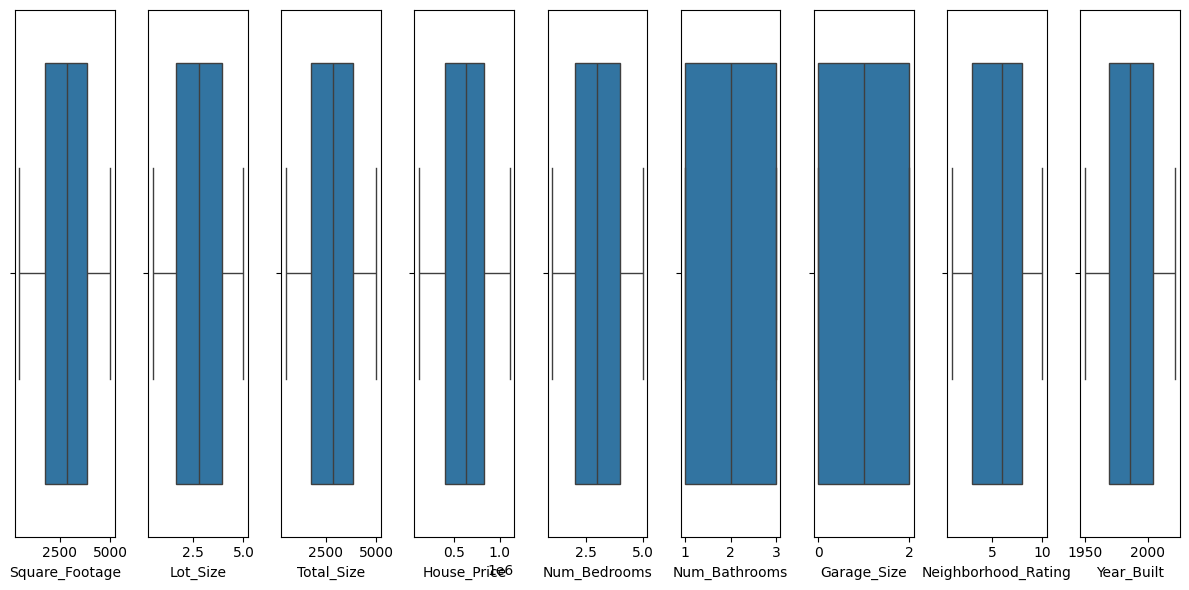

In [ ]:
fig,ax = plt.subplots(1,9,figsize=(12,6))
sns.boxplot(data,x='Square_Footage',ax=ax[0])
sns.boxplot(data,x='Lot_Size',ax=ax[1])
sns.boxplot(data,x='Total_Size',ax=ax[2])
sns.boxplot(data,x='House_Price',ax=ax[3])
sns.boxplot(data,x='Num_Bedrooms',ax=ax[4])
sns.boxplot(data,x='Num_Bathrooms',ax=ax[5])
sns.boxplot(data,x='Garage_Size',ax=ax[6])
sns.boxplot(data,x='Neighborhood_Rating',ax=ax[7])
sns.boxplot(data,x='Year_Built',ax=ax[8])
plt.tight_layout()

There are  no outliers .

So not required to find the outliers.

In [ ]:
# Incase outliers are there use the below steps.

**Find Outliers**
1. IQR(Inter quartile range): Used when data distribution is skewed.
2. 3-sigma rule : Used when data is normal
3. Outliers should handled only if % of outliers are less than 5%.

## **Encoding Techniques**

The process of converting text to numerical so that machine can can understand.

* Label Encoder
* One hot Encoder
* Ordinal Encoder
* Target Encoder
* Manual Encoder

In [ ]:
# NO Categorical column.
# therfore no encoding Techniques.

#Scaling
If there is a huge variation among the values in different numerical column we using scaling to bring all the values to a same scale so that calculations becomes easy.

* Minmax scaler
* Standard scaler

#Minmax scaler
It transforms all the values into a range of 0 to 1

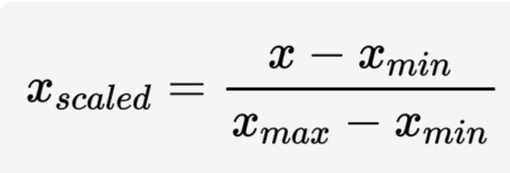

In [ ]:
df = data.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Square_Footage']] = scaler.fit_transform(data[['Square_Footage']])
df[['Lot_Size']] = scaler.fit_transform(data[['Lot_Size']])

In [ ]:
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Rating,House_Price,Total_Size
0,0.190614,2,1,1981,0.020873,0,5,2.623829e+05,1360.599637
1,0.838301,3,3,2016,0.947295,1,6,9.852609e+05,4276.753014
2,0.687055,1,2,2016,0.697880,0,9,7.779774e+05,3595.634823
3,0.102980,1,2,1977,0.496205,1,8,2.296989e+05,968.730667
4,0.983763,2,1,1993,0.935263,0,8,1.041741e+06,4930.699073
...,...,...,...,...,...,...,...,...,...
995,0.613434,4,1,1978,0.370056,2,10,7.014940e+05,3263.165110
996,0.595196,1,2,1999,0.551178,1,10,6.837232e+05,3181.977123
997,0.467749,4,2,1962,0.791616,0,2,5.720240e+05,2610.055067
998,0.938612,5,2,1950,0.317820,0,7,9.648653e+05,4724.930921


# Log Transformation
- Usually applied on target column only in regression.
- It is used to transform skewed data into normal distribution.
- Linear regression expects data distribution of target to be normal.

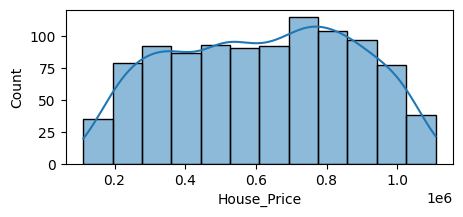

In [ ]:
# charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='House_Price',kde=True)
plt.show()


In [ ]:
# Already the bata is in the form of Normal Distribution.
# Log transform is not required.

# Feature Engineering
* Select best features
* drop the columns
* create a new column

# Split data for x and y

In [ ]:
x = data.drop(columns='House_Price')
y= data['House_Price']

# Split data for training and testing

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
x_train.shape

(700, 8)

In [ ]:
x_test.shape

(300, 8)

# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
# train model with x_train , y_train
model.fit(x_train,y_train)
# make predictions using x_test
y_pred = model.predict(x_test)


In [ ]:
# slope
model.coef_

array([-4815.39872803, 10238.03688511,  8312.14002512,  1002.74791327,
        9830.15112699,  5202.22558931,   132.23837803,  5014.75239897])

In [ ]:
#intercept
model.intercept_

np.float64(-2028685.9383585625)

# Evaluate the Regression

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
# mean squared error
mean_squared_error(y_test,y_pred)

102281056.95767306

In [ ]:
# mean_absolute error
mean_absolute_error(y_test,y_pred)

8089.577891535248

In [ ]:
# rmse
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(10113.409759209455)

In [ ]:
# mape
mean_absolute_percentage_error(y_test,y_pred)

0.016555074954279058

In [ ]:
# r2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
r2

0.9840673374358888

In [ ]:
# n is number of rows
n = x_test.shape[0]
n # number of rows

300

In [ ]:
# p : no of columns
p = x_test.shape[1]
p

8

In [ ]:
# adjusted r2
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.9836293260939202

# KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
mean_squared_error(y_test,y_pred)

1004492304.1794894

In [ ]:
mean_absolute_error(y_test,y_pred)

25845.461695194706

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(31693.72657450508)

In [ ]:
mean_absolute_percentage_error(y_test,y_pred)

0.05407524383459189

In [ ]:
r2 =r2_score(y_test,y_pred)
r2

0.984266590605623

In [ ]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.983834057014025

# how to find K

In [ ]:
error=[]
for k in range(2,11):
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  error.append(rmse)
print(error)

[np.float64(35701.84058205237), np.float64(32990.14278672819), np.float64(32241.32538578439), np.float64(31693.72657450508), np.float64(32061.794962671465), np.float64(32110.610555167452), np.float64(32056.11955047256), np.float64(32046.542143620136), np.float64(31893.785152947003)]


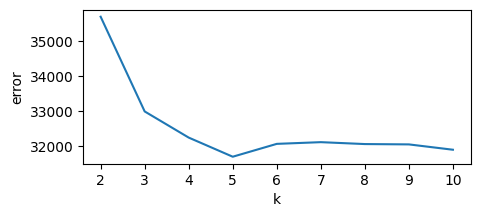

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error)
plt.xlabel('k')
plt.ylabel('error')
plt.show()



---
---

1. Square Footage is the most important factor affecting house price. Bigger houses have higher prices.


2. Lot Size also has a positive impact. Houses with larger land area tend to be more expensive.


3. Bedrooms and bathrooms influence the price slightly, but not as much as the size of the house.


4. The dataset is clean (no missing values, no duplicates, no outliers), which helped the model perform well.


5. House price data is almost normally distributed, so log transformation was not required.


6. Linear Regression gave very high accuracy, with very low error and R² score close to 1.


7. KNN Regressor was also tested, and the best value of K was found using an error vs K graph.

---
---


# **CONCLUSION**


This project successfully built a machine learning regression model to predict house prices using important features such as square footage, number of bedrooms, number of bathrooms, lot size, garage size, neighborhood quality, and year built.


Through Exploratory Data Analysis, it was found that the size of the house plays the most important role in determining the price. After preprocessing the dataset and applying Linear Regression, the model achieved a very high prediction accuracy with minimal error.

Therefore, this project demonstrates how machine learning techniques can be effectively used in the real estate industry to estimate house prices accurately and support better decision-making.